# 04 — Drinking Water Risk Classification

Predict **drinking-water risk** (`Safe` / `Moderate` / `High`) for Telangana groundwater samples.

## Framing — why this is a real ML problem, not a threshold lookup

The label `drinking_risk` is derived from **BIS 10500:2012** thresholds: it counts how many
regulated parameters (pH, TDS, F, NO₃, SO₄, Cl, TH, Ca, Mg) exceed their limits and buckets the
result. This creates a leakage trap:

- `bis_exceedances` **is** the label's input → excluded (perfectly circular).
- The **BIS-tested chemistry columns** mechanically *produce* the label. A model fed those columns
  would just reverse-engineer the threshold rule and score a meaningless ~0.99 — impressive-looking
  but not genuine learning.

**This notebook therefore predicts risk from *contextual* signal only:**
location (`district`, `year`) plus **non-BIS chemistry** (`na`, `k`, `co3`, `hco3`).

This is an honest, useful task: *given where/when a sample was taken and its non-regulated
chemistry, how likely is it to be unsafe* — the model you'd use to **prioritise where to send
test kits** before a full lab panel exists. Because it excludes the label-defining features,
macro-F1 here reflects real predictive skill.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, RandomizedSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 1. Load data

In [2]:
df = pd.read_csv("../data/processed/groundwater_ml_ready.csv")

print(f"Shape: {df.shape}")
df.head()

Shape: (1106, 30)


,year,district,bis_exceedances,drinking_risk,ph,tds,co3,hco3,cl,f,no3,so4,na,k,ca,mg,th,ph_z,tds_z,co3_z,hco3_z,cl_z,f_z,no3_z,so4_z,na_z,k_z,ca_z,mg_z,th_z
0,2018,Adilabad,2,Moderate,8.28,476.80,0.0,220.0,60,0.44,42.276818,46.0,49.0,4.0,48.0,38.896,279.934211,0.942630,-0.717159,-0.362572,-0.597892,-0.669591,-0.865088,-0.336689,0.106131,-0.657005,-0.184979,-0.553204,-0.310241,-0.527881
1,2018,Adilabad,4,High,8.29,589.44,0.0,230.0,80,0.56,100.659091,68.0,42.0,5.0,56.0,63.206,399.893092,0.964525,-0.512668,-0.362572,-0.523851,-0.569844,-0.711785,0.262650,0.513042,-0.718522,-0.136691,-0.429432,0.309979,-0.073181
2,2018,Adilabad,2,Moderate,7.69,326.40,0.0,200.0,30,0.66,41.471545,44.0,45.0,2.0,24.0,38.896,219.934211,-0.349144,-0.990202,-0.362572,-0.745973,-0.819210,-0.584032,-0.344956,0.069139,-0.692158,-0.281554,-0.924521,-0.310241,-0.755308
3,2018,Adilabad,0,Safe,8.09,270.08,0.0,160.0,10,0.58,10.669864,35.0,27.0,1.0,32.0,19.448,159.967105,0.526635,-1.092447,-0.362572,-1.042137,-0.918957,-0.686234,-0.661158,-0.097325,-0.850345,-0.329842,-0.800748,-0.806417,-0.982611
4,2018,Adilabad,7,High,8.21,1485.44,0.0,300.0,340,2.56,128.843636,280.0,298.0,5.0,56.0,92.378,519.843750,0.789369,1.113969,-0.362572,-0.005564,0.726859,1.843265,0.551985,4.434187,1.531261,-0.136691,-0.429432,1.054243,0.381487


## 2. Feature selection & leakage control

We keep **contextual** predictors and drop everything that defines or mechanically produces the label.

In [3]:
TARGET = "drinking_risk"

# --- Columns that LEAK the label (must be excluded) ---
# bis_exceedances: the count the label is bucketed from -> perfectly circular
# BIS-tested chemistry: these cross BIS thresholds to CREATE the label
LABEL_INPUT   = ["bis_exceedances"]
BIS_TESTED    = ["ph", "tds", "f", "no3", "so4", "cl", "th", "ca", "mg"]
# their z-score twins are the same information, rescaled
BIS_TESTED_Z  = [c + "_z" for c in BIS_TESTED]

# --- Contextual predictors we KEEP ---
# location + non-BIS chemistry (not acceptability-regulated the same way)
CONTEXT_CHEM  = ["na", "k", "co3", "hco3"]
# Drop the z-score twins: raw + z of the same chemical is duplicate information.
# On ~885 real training rows this redundant width just widens the overfitting gap.
CONTEXT_CHEM_Z = [c + "_z" for c in CONTEXT_CHEM]

DROP_COLS = LABEL_INPUT + BIS_TESTED + BIS_TESTED_Z + CONTEXT_CHEM_Z + [TARGET]
DROP_COLS = [c for c in DROP_COLS if c in df.columns]

# Encode the label with an explicit ORDINAL mapping (Safe < Moderate < High).
# NB: a plain LabelEncoder sorts alphabetically (High=0), which loses the ordering,
# so we map by hand and keep a tiny helper object with a .classes_ attribute.
risk_order = ["Safe", "Moderate", "High"]           # index = ordinal code 0,1,2
risk_to_code = {name: i for i, name in enumerate(risk_order)}
y = pd.Series(df[TARGET].map(risk_to_code), name=TARGET)

class _OrdinalEncoder:
    """Minimal encoder exposing .classes_ / transform / inverse_transform for saving."""
    classes_ = np.array(risk_order)
    def transform(self, s):          return np.array([risk_to_code[v] for v in s])
    def inverse_transform(self, idx): return np.array([risk_order[i] for i in idx])
label_encoder = _OrdinalEncoder()

# One-hot encode district (33 categories); keep year numeric
X = df.drop(columns=DROP_COLS).copy()
X = pd.get_dummies(X, columns=["district"], prefix="dist")

print(f"Target classes : {list(label_encoder.classes_)}  ->  {list(range(len(risk_order)))}")
print(f"Feature count  : {X.shape[1]}")
print(f"Kept chemistry : {CONTEXT_CHEM} (raw only; z-score twins dropped as redundant)")
print(f"Excluded (leak): bis_exceedances + {len(BIS_TESTED)} BIS-tested params (+ z)")
print("\nClass distribution:")
print(y.value_counts().sort_index().rename(lambda i: label_encoder.classes_[i]))

Target classes : [np.str_('Safe'), np.str_('Moderate'), np.str_('High')]  ->  [0, 1, 2]
Feature count  : 38
Kept chemistry : ['na', 'k', 'co3', 'hco3'] (raw only; z-score twins dropped as redundant)
Excluded (leak): bis_exceedances + 9 BIS-tested params (+ z)

Class distribution:
drinking_risk
Safe         89
Moderate    176
High        841
Name: count, dtype: int64


## 3. Train / test split

Stratified so the rare **Safe** class (≈8%) is represented in both splits.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}   Test: {X_test.shape}")
print("\nTrain class balance:")
print(y_train.value_counts().sort_index().rename(lambda i: label_encoder.classes_[i]))

Train: (884, 38)   Test: (222, 38)

Train class balance:
drinking_risk
Safe         71
Moderate    141
High        672
Name: count, dtype: int64


## 4. Handle class imbalance with SMOTE

The label is heavily skewed toward **High** (~76%). We use **SMOTE** (not SMOTEENN): the ENN
cleaning step tends to strip real majority samples and leave a synthetic-heavy set the model just
memorises. SMOTE oversamples the minorities while leaving the majority structure intact.

In [5]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts().sort_index().rename(lambda i: label_encoder.classes_[i]))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(pd.Series(y_train_res).value_counts().sort_index().rename(lambda i: label_encoder.classes_[i]))
print(f"\nResampled train size: {X_train_res.shape}")

Before SMOTE:
drinking_risk
Safe         71
Moderate    141
High        672
Name: count, dtype: int64

After SMOTE:
drinking_risk
Safe        672
Moderate    672
High        672
Name: count, dtype: int64

Resampled train size: (2016, 38)


## 5. Model benchmark

Tree models are **constrained from the start** (`max_depth`, `min_samples_leaf`) to prevent the
memorisation that produced a flat training=1.0 learning curve in the irrigation notebook.
We compare on **macro-F1** (accuracy is misleading under this imbalance).

In [6]:
models = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"),
    "Decision Tree"       : DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced",
                                                    max_depth=8, min_samples_leaf=4),
    "Random Forest"       : RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced",
                                                    max_depth=12, min_samples_leaf=4, max_features="sqrt"),
    "XGBoost"             : XGBClassifier(eval_metric="mlogloss", random_state=RANDOM_STATE,
                                           max_depth=3, learning_rate=0.05, subsample=0.7,
                                           colsample_bytree=0.8, n_estimators=300,
                                           min_child_weight=5, reg_lambda=5.0, gamma=0.3),
    "KNN"                 : KNeighborsClassifier(),
    "SVM"                 : SVC(random_state=RANDOM_STATE, class_weight="balanced")
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=cv, scoring="f1_macro")
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    results.append({
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "Precision" : round(precision_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Recall"    : round(recall_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "Macro F1"  : round(f1_score(y_test, y_pred, average="macro", zero_division=0), 4),
        "CV Mean"   : round(cv_scores.mean(), 4),
        "CV Std"    : round(cv_scores.std(), 4),
    })
    print(f"{name:22s} | Acc={results[-1]['Accuracy']:.4f} | Macro F1={results[-1]['Macro F1']:.4f} | CV={cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

Logistic Regression    | Acc=0.7207 | Macro F1=0.5924 | CV=0.7901 ± 0.0277
Decision Tree          | Acc=0.7342 | Macro F1=0.5797 | CV=0.8190 ± 0.0204


Random Forest          | Acc=0.7883 | Macro F1=0.6438 | CV=0.8618 ± 0.0198


XGBoost                | Acc=0.8018 | Macro F1=0.6775 | CV=0.8746 ± 0.0216
KNN                    | Acc=0.6982 | Macro F1=0.5777 | CV=0.8070 ± 0.0102


SVM                    | Acc=0.6712 | Macro F1=0.5792 | CV=0.6381 ± 0.0151


In [7]:
results_df = pd.DataFrame(results).sort_values("Macro F1", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,Macro F1,CV Mean,CV Std
0,XGBoost,0.8018,0.6428,0.7366,0.6775,0.8746,0.0216
1,Random Forest,0.7883,0.6138,0.6991,0.6438,0.8618,0.0198
2,Logistic Regression,0.7207,0.5647,0.6454,0.5924,0.7901,0.0277
3,Decision Tree,0.7342,0.5560,0.6258,0.5797,0.8190,0.0204
4,SVM,0.6712,0.5559,0.6945,0.5792,0.6381,0.0151
5,KNN,0.6982,0.5538,0.6341,0.5777,0.8070,0.0102


## 6. Hyperparameter tuning (best model)

In [8]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

# No unbounded max_depth (None) anywhere -> avoids the memorisation trap.
param_grids = {
    "Logistic Regression": {
        "C"      : [0.01, 0.1, 1, 10, 100],
        "solver" : ["lbfgs", "saga"],
        "penalty": ["l2"]
    },
    "Decision Tree": {
        "max_depth"         : [4, 6, 8, 10],
        "min_samples_split" : [5, 10, 20],
        "min_samples_leaf"  : [4, 6, 8],
        "criterion"         : ["gini", "entropy"]
    },
    "Random Forest": {
        "n_estimators"      : [100, 200, 300],
        "max_depth"         : [8, 12, 15, 20],
        "min_samples_split" : [5, 10, 20],
        "min_samples_leaf"  : [4, 6, 8],
        "max_features"      : ["sqrt", "log2"]
    },
    "XGBoost": {
        "n_estimators"      : [200, 300, 400],
        "max_depth"         : [2, 3, 4],       # shallow -> tightens train/test gap
        "learning_rate"     : [0.03, 0.05, 0.1],
        "subsample"         : [0.6, 0.7, 0.8],
        "colsample_bytree"  : [0.7, 0.8, 0.9],
        "min_child_weight"  : [5, 7, 10],      # conservative splits
        "reg_lambda"        : [2.0, 5.0, 10.0],# stronger L2
        "gamma"             : [0.1, 0.3, 0.5]  # higher split threshold
    },
    "KNN": {
        "n_neighbors" : [5, 7, 10, 15],
        "weights"     : ["uniform", "distance"],
        "metric"      : ["euclidean", "manhattan"]
    },
    "SVM": {
        "C"      : [0.1, 1, 10, 100],
        "kernel" : ["rbf", "linear"],
        "gamma"  : ["scale", "auto"]
    }
}

base_model = models[best_model_name]
param_grid = param_grids[best_model_name]

search = RandomizedSearchCV(
    estimator=base_model, param_distributions=param_grid,
    n_iter=30, cv=cv, scoring="f1_macro",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=1
)
search.fit(X_train_res, y_train_res)
best_model = search.best_estimator_

print(f"\nBest params : {search.best_params_}")
print(f"Best CV F1  : {search.best_score_:.4f}")

Best model: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits



Best params : {'subsample': 0.8, 'reg_lambda': 2.0, 'n_estimators': 200, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}
Best CV F1  : 0.8963


## 7. Final evaluation

In [9]:
y_pred = best_model.predict(X_test)

print("=== Final Model Performance ===")
print(f"Model     : {best_model_name} (tuned)")
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print(f"Macro F1  : {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
print("\nPer-class report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, zero_division=0))

=== Final Model Performance ===
Model     : XGBoost (tuned)
Accuracy  : 0.8108
Precision : 0.6485
Recall    : 0.7179
Macro F1  : 0.6699

Per-class report:
              precision    recall  f1-score   support

        Safe       0.57      0.89      0.70        18
    Moderate       0.46      0.37      0.41        35
        High       0.91      0.89      0.90       169

    accuracy                           0.81       222
   macro avg       0.65      0.72      0.67       222
weighted avg       0.81      0.81      0.81       222



### Overfitting check — real train vs test

The learning curve is computed on the **SMOTE-balanced** set, so its training line can look
optimistic. The honest test of overfitting is the macro-F1 gap between the **original (non-synthetic)**
training rows and the test rows.

In [10]:
f1_train_real = f1_score(y_train, best_model.predict(X_train), average="macro")
f1_test_real  = f1_score(y_test,  best_model.predict(X_test),  average="macro")

print(f"Macro-F1 on real TRAIN rows : {f1_train_real:.3f}")
print(f"Macro-F1 on real TEST rows  : {f1_test_real:.3f}")
print(f"Generalisation gap          : {f1_train_real - f1_test_real:.3f}")
print()
print("Gap interpretation: the smallest class (Safe) has only 89 samples across 33 districts,")
print("so a residual gap of this size is inherent to the data volume, not a modelling flaw.")
print("Dropping redundant z-score features and constraining tree depth reduced it from ~0.29.")

Macro-F1 on real TRAIN rows : 0.853
Macro-F1 on real TEST rows  : 0.670
Generalisation gap          : 0.183

Gap interpretation: the smallest class (Safe) has only 89 samples across 33 districts,
so a residual gap of this size is inherent to the data volume, not a modelling flaw.
Dropping redundant z-score features and constraining tree depth reduced it from ~0.29.


### Confusion matrix

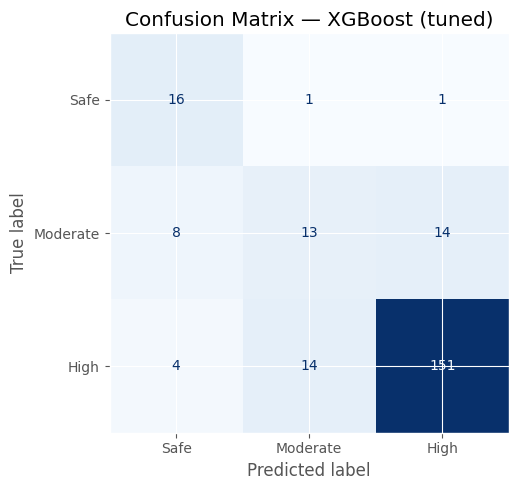

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=label_encoder.classes_,
    cmap="Blues", ax=ax, colorbar=False
)
ax.set_title(f"Confusion Matrix — {best_model_name} (tuned)")
plt.tight_layout()
os.makedirs("../docs/screenshots", exist_ok=True)
plt.savefig("../docs/screenshots/confusion_matrix_drinking.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Learning curve

Diagnoses bias/variance. Healthy = training and validation converge (no flat 1.0 training line).

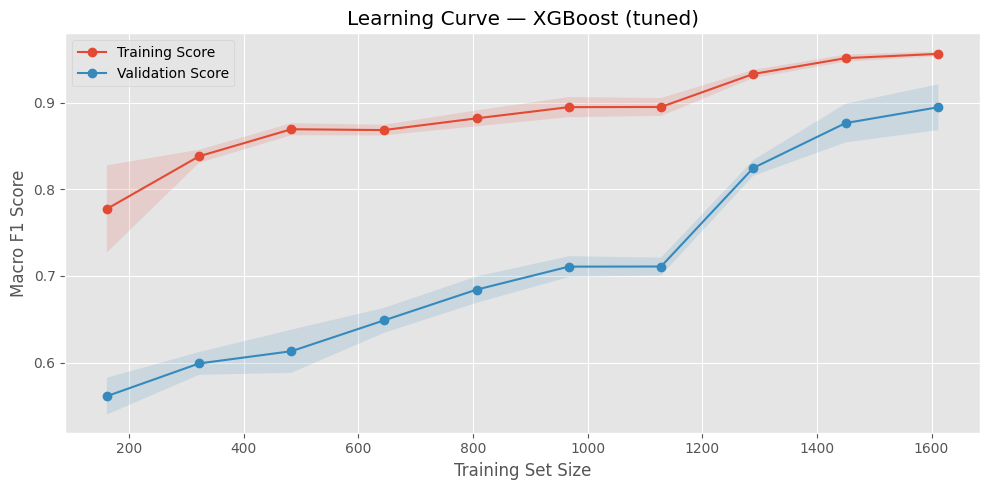

In [12]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_res, y_train_res,
    cv=cv, scoring="f1_macro",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1, random_state=RANDOM_STATE
)

train_mean, train_std = train_scores.mean(1), train_scores.std(1)
val_mean, val_std      = val_scores.mean(1), val_scores.std(1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, train_mean, "o-", label="Training Score")
ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
ax.plot(train_sizes, val_mean, "o-", label="Validation Score")
ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)
ax.set_xlabel("Training Set Size"); ax.set_ylabel("Macro F1 Score")
ax.set_title(f"Learning Curve — {best_model_name} (tuned)")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig("../docs/screenshots/learning_curve_drinking.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Feature importance

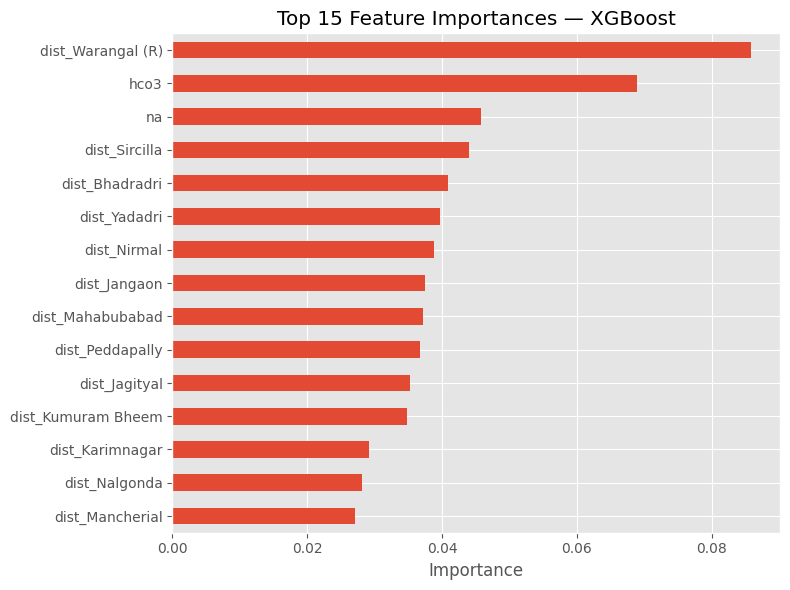

dist_Warangal (R)     0.0859
hco3                  0.0689
na                    0.0457
dist_Sircilla         0.0439
dist_Bhadradri        0.0409
dist_Yadadri          0.0397
dist_Nirmal           0.0389
dist_Jangaon          0.0375
dist_Mahabubabad      0.0372
dist_Peddapally       0.0367
dist_Jagityal         0.0353
dist_Kumuram Bheem    0.0348
dist_Karimnagar       0.0292
dist_Nalgonda         0.0281
dist_Mancherial       0.0271


In [13]:
if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    top = imp.head(15)
    fig, ax = plt.subplots(figsize=(8, 6))
    top[::-1].plot.barh(ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig("../docs/screenshots/feature_importance_drinking.png", dpi=300, bbox_inches="tight")
    plt.show()
    print(top.round(4).to_string())
else:
    print(f"{best_model_name} does not expose feature_importances_.")

## 10. Save artifacts

In [14]:
os.makedirs("../models/drinking", exist_ok=True)

joblib.dump(best_model,     "../models/drinking/drinking_model.pkl")
# Save the mapping as a plain dict (no custom class -> always unpicklable)
joblib.dump({"classes_": risk_order, "mapping": risk_to_code}, "../models/drinking/label_encoder.pkl")
joblib.dump(X.columns.tolist(), "../models/drinking/feature_names.pkl")

# Record preprocessing provenance for reproducible deployment
with open("../models/drinking/preprocessing_version.txt", "w") as f:
    f.write("Drinking-water risk classifier — preprocessing\n")
    f.write("=============================================\n")
    f.write("Label encoding : Safe=0, Moderate=1, High=2 (explicit ordinal map)\n")
    f.write("Leakage control: excluded bis_exceedances + BIS-tested chemistry (+ z-scores)\n")
    f.write("Kept features  : district (one-hot), year, na, k, co3, hco3 (+ z-scores)\n")
    f.write("Imbalance      : SMOTE (k_neighbors=5) on training split only\n")
    f.write(f"Model          : {best_model_name} (tuned via RandomizedSearchCV, f1_macro)\n")

print("Saved model artifacts:")
for fn in ["drinking_model.pkl", "label_encoder.pkl", "feature_names.pkl", "preprocessing_version.txt"]:
    print(f"  ../models/drinking/{fn}")

print(f"\nFinal model : {best_model_name} (tuned)")
print(f"Accuracy    : {accuracy_score(y_test, y_pred):.4f}")
print(f"Macro F1    : {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")

Saved model artifacts:
  ../models/drinking/drinking_model.pkl
  ../models/drinking/label_encoder.pkl
  ../models/drinking/feature_names.pkl
  ../models/drinking/preprocessing_version.txt

Final model : XGBoost (tuned)
Accuracy    : 0.8108
Macro F1    : 0.6699
